In [13]:
# %%
# nn_cluster.py

In [14]:
# %%
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import neural_network
from sklearn.cluster import KMeans
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV, learning_curve, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
os.makedirs("./result", exist_ok=True)

In [15]:
# %%
# Load the Breast Cancer dataset
bc_data = load_breast_cancer()
X = bc_data.data
y = bc_data.target

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encode the target
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y.reshape(-1, 1))

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
# %%
# Apply clustering algorithms
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels_train = kmeans.fit_predict(X_train)
kmeans_labels_test = kmeans.predict(X_test)

em = GaussianMixture(n_components=2, random_state=42)
em_labels_train = em.fit_predict(X_train)
em_labels_test = em.predict(X_test)

# Add cluster labels as new features
X_train_kmeans = np.column_stack((X_train, kmeans_labels_train))
X_test_kmeans = np.column_stack((X_test, kmeans_labels_test))
X_train_em = np.column_stack((X_train, em_labels_train))
X_test_em = np.column_stack((X_test, em_labels_test))
X_train_combined = np.column_stack((X_train, kmeans_labels_train, em_labels_train))
X_test_combined = np.column_stack((X_test, kmeans_labels_test, em_labels_test))

In [17]:
# %%
# Train a neural network classifier
NeuralNetwork = neural_network.MLPClassifier(max_iter=3000, random_state=42)
param_grid = {
    "hidden_layer_sizes": np.arange(2, 50, 2),
    "activation": ["logistic", "relu", "tanh"],
    "solver": ["adam", "sgd"],
    "alpha": [0.001, 0.01, 0.1],
    "learning_rate": ["invscaling", "adaptive"],
    "learning_rate_init": [0.001, 0.01, 0.1],
}


def fit_and_evaluate(X_train, X_test, y_train, y_test, method_name):
    NeuralNetworkCV = GridSearchCV(
        NeuralNetwork, param_grid, cv=5, n_jobs=-1, verbose=1
    )

    start_time = time.time()
    NeuralNetworkCV.fit(X_train, y_train)
    end_time = time.time()

    training_time = end_time - start_time
    print(f"Training time ({method_name}): {training_time:.2f} seconds")
    print(f"Best parameters ({method_name}): {NeuralNetworkCV.best_params_}")

    y_train_pred = NeuralNetworkCV.predict(X_train)
    y_test_pred = NeuralNetworkCV.predict(X_test)

    train_score = NeuralNetworkCV.score(X_train, y_train)
    test_score = NeuralNetworkCV.score(X_test, y_test)
    print(f"Train accuracy ({method_name}): {train_score:.4f}")
    print(f"Test accuracy ({method_name}): {test_score:.4f}")

    precision = precision_score(y_test, y_test_pred, average="weighted")
    recall = recall_score(y_test, y_test_pred, average="weighted")
    f1 = f1_score(y_test, y_test_pred, average="weighted")
    roc_auc = roc_auc_score(y_test, y_test_pred, average="weighted")

    print(f"Precision ({method_name}): {precision:.4f}")
    print(f"Recall ({method_name}): {recall:.4f}")
    print(f"F1 Score ({method_name}): {f1:.4f}")
    print(f"ROC AUC Score ({method_name}): {roc_auc:.4f}")

    cm = confusion_matrix(y_test.argmax(axis=1), y_test_pred.argmax(axis=1))
    cm_df = pd.DataFrame(
        cm, index=encoder.categories_[0], columns=encoder.categories_[0]
    )
    cm_df.to_excel(f"./result/confusion_matrix_{method_name.lower()}.xlsx")
    print(f"Confusion Matrix ({method_name}):")
    print(cm_df)

    BestNeuralNetwork = NeuralNetworkCV.best_estimator_
    train_sizes, train_scores, test_scores = learning_curve(
        BestNeuralNetwork,
        X_train,
        y_train,
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 20),
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    return (
        NeuralNetworkCV.best_estimator_,
        train_sizes,
        train_scores_mean,
        train_scores_std,
        test_scores_mean,
        test_scores_std,
        train_score,
        test_score,
        training_time,
        precision,
        recall,
        f1,
        roc_auc,
    )

In [18]:
# %%
# Evaluate on original data with cluster labels
(
    best_nn_kmeans,
    train_sizes_kmeans,
    train_scores_mean_kmeans,
    train_scores_std_kmeans,
    test_scores_mean_kmeans,
    test_scores_std_kmeans,
    train_score_kmeans,
    test_score_kmeans,
    training_time_kmeans,
    precision_kmeans,
    recall_kmeans,
    f1_kmeans,
    roc_auc_kmeans,
) = fit_and_evaluate(X_train_kmeans, X_test_kmeans, y_train, y_test, "KMeans Clusters")

Fitting 5 folds for each of 2592 candidates, totalling 12960 fits
Training time (KMeans Clusters): 847.39 seconds
Best parameters (KMeans Clusters): {'activation': 'logistic', 'alpha': 0.001, 'hidden_layer_sizes': 10, 'learning_rate': 'adaptive', 'learning_rate_init': 0.01, 'solver': 'sgd'}
Train accuracy (KMeans Clusters): 0.9868
Test accuracy (KMeans Clusters): 0.9825
Precision (KMeans Clusters): 0.9825
Recall (KMeans Clusters): 0.9825
F1 Score (KMeans Clusters): 0.9825
ROC AUC Score (KMeans Clusters): 0.9813
Confusion Matrix (KMeans Clusters):
    0   1
0  42   1
1   1  70


In [19]:
# %%
(
    best_nn_em,
    train_sizes_em,
    train_scores_mean_em,
    train_scores_std_em,
    test_scores_mean_em,
    test_scores_std_em,
    train_score_em,
    test_score_em,
    training_time_em,
    precision_em,
    recall_em,
    f1_em,
    roc_auc_em,
) = fit_and_evaluate(X_train_em, X_test_em, y_train, y_test, "EM Clusters")

Fitting 5 folds for each of 2592 candidates, totalling 12960 fits
Training time (EM Clusters): 1066.77 seconds
Best parameters (EM Clusters): {'activation': 'logistic', 'alpha': 0.001, 'hidden_layer_sizes': 4, 'learning_rate': 'adaptive', 'learning_rate_init': 0.01, 'solver': 'sgd'}
Train accuracy (EM Clusters): 0.9846
Test accuracy (EM Clusters): 0.9825
Precision (EM Clusters): 0.9825
Recall (EM Clusters): 0.9825
F1 Score (EM Clusters): 0.9825
ROC AUC Score (EM Clusters): 0.9813
Confusion Matrix (EM Clusters):
    0   1
0  42   1
1   1  70


In [20]:
# %%
(
    best_nn_combined,
    train_sizes_combined,
    train_scores_mean_combined,
    train_scores_std_combined,
    test_scores_mean_combined,
    test_scores_std_combined,
    train_score_combined,
    test_score_combined,
    training_time_combined,
    precision_combined,
    recall_combined,
    f1_combined,
    roc_auc_combined,
) = fit_and_evaluate(
    X_train_combined, X_test_combined, y_train, y_test, "Combined Clusters"
)

Fitting 5 folds for each of 2592 candidates, totalling 12960 fits
Training time (Combined Clusters): 1033.35 seconds
Best parameters (Combined Clusters): {'activation': 'logistic', 'alpha': 0.001, 'hidden_layer_sizes': 16, 'learning_rate': 'adaptive', 'learning_rate_init': 0.001, 'solver': 'sgd'}
Train accuracy (Combined Clusters): 0.9824
Test accuracy (Combined Clusters): 0.9737
Precision (Combined Clusters): 0.9737
Recall (Combined Clusters): 0.9737
F1 Score (Combined Clusters): 0.9736
ROC AUC Score (Combined Clusters): 0.9697
Confusion Matrix (Combined Clusters):
    0   1
0  41   2
1   1  70


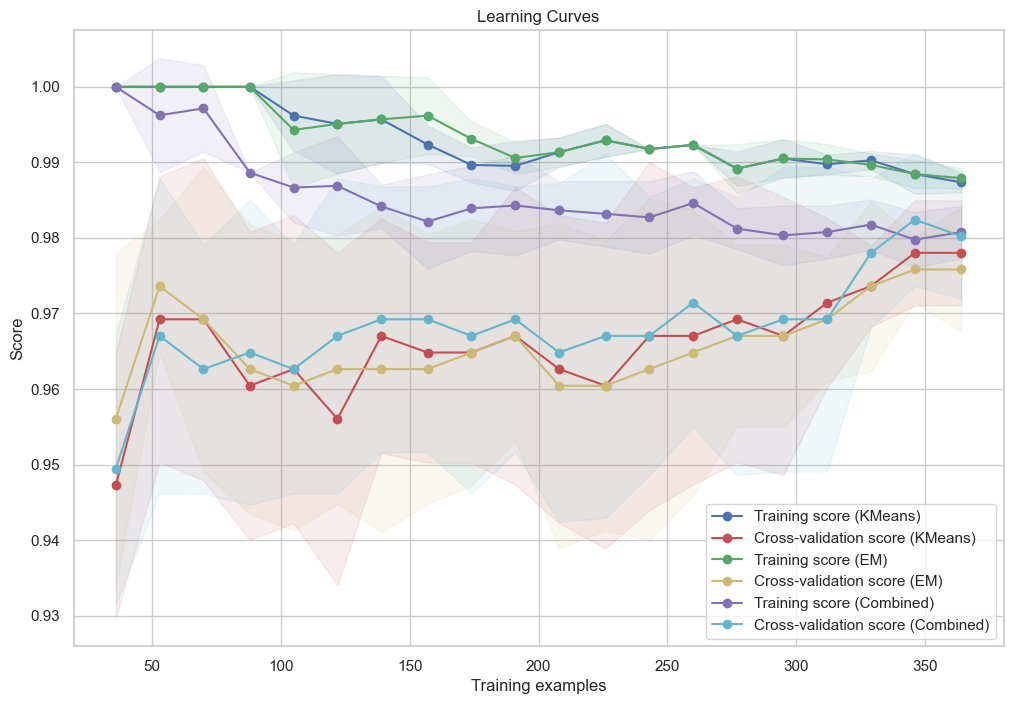

In [21]:
# %%
# Plot all learning curves in one figure
plt.figure(figsize=(12, 8))

# KMeans Clusters
plt.fill_between(
    train_sizes_kmeans,
    train_scores_mean_kmeans - train_scores_std_kmeans,
    train_scores_mean_kmeans + train_scores_std_kmeans,
    alpha=0.1,
    color="b",
)
plt.fill_between(
    train_sizes_kmeans,
    test_scores_mean_kmeans - test_scores_std_kmeans,
    test_scores_mean_kmeans + test_scores_std_kmeans,
    alpha=0.1,
    color="r",
)
plt.plot(
    train_sizes_kmeans,
    train_scores_mean_kmeans,
    "o-",
    color="b",
    label="Training score (KMeans)",
)
plt.plot(
    train_sizes_kmeans,
    test_scores_mean_kmeans,
    "o-",
    color="r",
    label="Cross-validation score (KMeans)",
)

# EM Clusters
plt.fill_between(
    train_sizes_em,
    train_scores_mean_em - train_scores_std_em,
    train_scores_mean_em + train_scores_std_em,
    alpha=0.1,
    color="g",
)
plt.fill_between(
    train_sizes_em,
    test_scores_mean_em - test_scores_std_em,
    test_scores_mean_em + test_scores_std_em,
    alpha=0.1,
    color="y",
)
plt.plot(
    train_sizes_em, train_scores_mean_em, "o-", color="g", label="Training score (EM)"
)
plt.plot(
    train_sizes_em,
    test_scores_mean_em,
    "o-",
    color="y",
    label="Cross-validation score (EM)",
)

# Combined Clusters
plt.fill_between(
    train_sizes_combined,
    train_scores_mean_combined - train_scores_std_combined,
    train_scores_mean_combined + train_scores_std_combined,
    alpha=0.1,
    color="m",
)
plt.fill_between(
    train_sizes_combined,
    test_scores_mean_combined - test_scores_std_combined,
    test_scores_mean_combined + test_scores_std_combined,
    alpha=0.1,
    color="c",
)
plt.plot(
    train_sizes_combined,
    train_scores_mean_combined,
    "o-",
    color="m",
    label="Training score (Combined)",
)
plt.plot(
    train_sizes_combined,
    test_scores_mean_combined,
    "o-",
    color="c",
    label="Cross-validation score (Combined)",
)

plt.title("Learning Curves")
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.legend(loc="best")
plt.savefig("./result/learning_curve_combined.png", dpi=300)
plt.show()

In [22]:
# %%
# Compile results into a DataFrame
results = {
    "Method": ["KMeans Clusters", "EM Clusters", "Combined Clusters"],
    "Train Accuracy": [
        train_score_kmeans,
        train_score_em,
        train_score_combined,
    ],
    "Test Accuracy": [
        test_score_kmeans,
        test_score_em,
        test_score_combined,
    ],
    "Training Time (s)": [
        training_time_kmeans,
        training_time_em,
        training_time_combined,
    ],
    "Precision": [
        precision_kmeans,
        precision_em,
        precision_combined,
    ],
    "Recall": [
        recall_kmeans,
        recall_em,
        recall_combined,
    ],
    "F1 Score": [
        f1_kmeans,
        f1_em,
        f1_combined,
    ],
    "ROC AUC Score": [
        roc_auc_kmeans,
        roc_auc_em,
        roc_auc_combined,
    ],
}

results_df = pd.DataFrame(results)
print(results_df)

results_df.to_excel(
    "./result/nn_performance_with_clusters_comparison.xlsx", index=False
)

print("Results saved to './result/nn_performance_with_clusters_comparison.xlsx'")

              Method  Train Accuracy  Test Accuracy  Training Time (s)  \
0    KMeans Clusters        0.986813       0.982456         847.392089   
1        EM Clusters        0.984615       0.982456        1066.765557   
2  Combined Clusters        0.982418       0.973684        1033.354112   

   Precision    Recall  F1 Score  ROC AUC Score  
0   0.982456  0.982456  0.982456       0.981330  
1   0.982456  0.982456  0.982456       0.981330  
2   0.973719  0.973684  0.973621       0.969702  
Results saved to './result/nn_performance_with_clusters_comparison.xlsx'


In [23]:
# %%